# Определение возраста покупателей

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
* Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
* Контролировать добросовестность кассиров при продаже алкоголя.

Нужно построить модель, которая по фотографии определит приблизительный возраст человека. В нашем распоряжении набор фотографий людей с указанием возраста.

Проект будет выполняться поэтапно, вот что нас ждёт:
 1) Исследовательский анализ данных.
 
 2) Обучение модели.
 
 3) Анализ обученной модели.
 
# Анализ поставленной задачи

По фотографии нужно определить возраст человека, это непосредственно задача регрессии, ведь число в ответе — это количество лет. Функцию потерь в тком случае для оптимизации мы будем использовать именно Mean Squared Error

## Исследовательский анализ данных

Для начала загрузим необходимые библиотеки

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter

Теперь загрузим наш датасет и разделим на выборки и выведем на экран их размеры, редварительно проведя маштабирование фотографий при загрузке и деля выборку на 32 батча.

In [2]:
labels = pd.read_csv('/datasets/faces/labels.csv')
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        subset='training',
        class_mode='raw',
        seed=12345) 
test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        subset='validation',
        class_mode='raw',
        seed=12345) 

Found 6073 validated image filenames.
Found 1518 validated image filenames.


Отлично! Теперь мы знаем размеры выборок! Давайте проанализируем возраст и сами фотографии в батчах


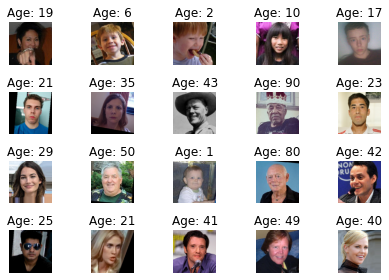

In [12]:
images, labels = next(train_gen_flow)

for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i])
    plt.title(f'Age: {labels[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Можем заметить, что целевой признак записан как обычное число, одной фотографии соответсвует кол-во лет, есть некоторое кол-во фотографий, которое немного видоизменненно, а именно: есть некоторый угол поворота фотографий, есть несколько фотографий с изменённм маштабом(зумом), имеется различный фон, лица смотрят в разные стороны.Всё это прокладывает положительную динамику в результативности модели, ведь модель сможет распознавать возраст более корректно под разным углом и на разном расстоянии

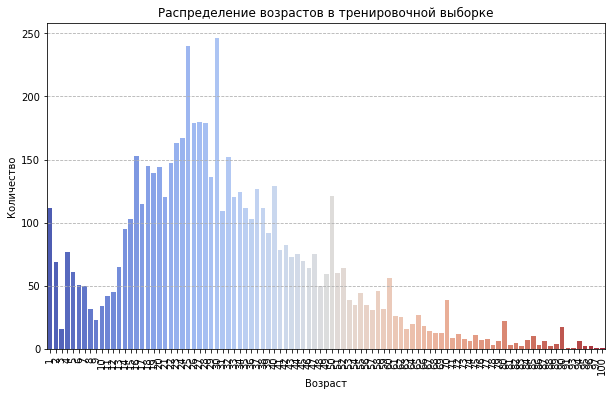

In [4]:

age_counter = Counter()
# Пройти по всем батчам в генераторе
for i in range(len(train_gen_flow)):
    images, ages = train_gen_flow.next()  # Получение следующего батча изображений и меток
    age_counter.update(ages.astype(int)) 
import seaborn as sns
value_counts = pd.Series(dict(age_counter))
# Создаем гистограмму с помощью seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=value_counts.index, y=value_counts.values, palette='coolwarm')
plt.title('Распределение возрастов в тренировочной выборке')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.xticks(rotation=90)  # Поворот меток на оси X для лучшей читабельности
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

В ходе анализа графика можем заметить, что возраст людей в выборке лежит на диапазоне значений от 1 до 100, и очень много фотографий с возростом от 17 до 41, вероятно, это самые распрастранённый возраст - люди которые родились до того как раждаемость превысила смертность и началась вновь. очень много так же фотографий с возрастом от 1 до 9 лет, это так же активный возраст, люди часто возят своих детей по различным мероприятиям и хотят запечатлить этот момент, поэтому везде фотают детей, а вот с приклонным возрастом (вплоть до 100 лет) всё реже и реже появляются фотографии - это связанно с уменьшением мобильности с возрастом, и то что всё реже люди могут дожить до такого возраста. Из этого можно сформировать вывод что наша модель очень хорошо сможет предсказывать числа от 1 до 60 , а далее с увиличением погрешность будет расти.

## Обучение модели

Построим и обучим свёрточную нейронную сеть на датасете с фотографиями людей. Важное требование заказчика - добиться значения MAE на тестовой выборке не больше 8.

```python
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AvgPool2D, Flatten, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np
from tensorflow.keras.applications.resnet import ResNet50
import pandas as pd

def load_train(path):
    datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.1, 
        height_shift_range=0.1,
        zoom_range=(0.8, 0.8),
        horizontal_flip=True,
        rescale=1. / 255,
        validation_split=0.25
    )

    train_datagen_flow = datagen.flow_from_dataframe(
        dataframe=pd.read_csv(path + 'labels.csv'),
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345
    )
    return train_datagen_flow

def load_test(path):
    datagen = ImageDataGenerator(
        rescale=1. / 255,
        validation_split=0.25
    )

    test_datagen_flow = datagen.flow_from_dataframe(
        dataframe=pd.read_csv(path + 'labels.csv'),
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345
    )
    return test_datagen_flow

def create_model(input_shape):
    backbone = ResNet50(input_shape=input_shape,
                        weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
                        #weights='imagenet',
                        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer_adam = Adam(lr=.001)
    model.compile(optimizer=optimizer_adam,
                  loss='mean_squared_error',
                  metrics=['mae'])
    model.summary()

    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=30,
                steps_per_epoch=None, validation_steps=None):
    train_datagen_flow = train_data
    test_datagen_flow = test_data
    model.fit(train_datagen_flow,
              validation_data=test_datagen_flow,
              batch_size=batch_size,
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)
    return model

```

```

Found 5694 validated image filenames.
Found 1897 validated image filenames.
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
resnet50 (Model)             (None, 7, 7, 2048)        23587712  
_________________________________________________________________
global_average_pooling2d (Gl (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 1)                 2049      
=================================================================
Total params: 23,589,761
Trainable params: 23,536,641
Non-trainable params: 53,120
Train for 178 steps, validate for 60 steps
Epoch 1/30
178/178 - 127s - loss: 254.7669 - mae: 11.6309 - val_loss: 830.3840 - val_mae: 23.9256
Epoch 2/30
178/178 - 106s - loss: 109.6471 - mae: 7.8788 - val_loss: 600.1756 - val_mae: 19.4701
Epoch 3/30
178/178 - 100s - loss: 90.5179 - mae: 7.2098 - val_loss: 372.9882 - val_mae: 14.4792
Epoch 4/30
178/178 - 100s - loss: 75.9353 - mae: 6.5686 - val_loss: 134.7926 - val_mae: 8.6574
Epoch 5/30
178/178 - 104s - loss: 65.7139 - mae: 6.2385 - val_loss: 89.1565 - val_mae: 7.1571
Epoch 6/30
178/178 - 100s - loss: 60.2881 - mae: 5.8949 - val_loss: 84.1938 - val_mae: 6.7532
Epoch 7/30
178/178 - 99s - loss: 51.1771 - mae: 5.5207 - val_loss: 89.4036 - val_mae: 6.9285
Epoch 8/30
178/178 - 99s - loss: 46.5834 - mae: 5.2276 - val_loss: 123.2163 - val_mae: 7.8909
Epoch 9/30
178/178 - 99s - loss: 43.5914 - mae: 4.9993 - val_loss: 74.3332 - val_mae: 6.5739
Epoch 10/30
178/178 - 99s - loss: 37.8555 - mae: 4.7257 - val_loss: 87.5640 - val_mae: 7.0829
Epoch 11/30
178/178 - 99s - loss: 38.0593 - mae: 4.6835 - val_loss: 98.6746 - val_mae: 7.2895
Epoch 12/30
178/178 - 99s - loss: 31.5450 - mae: 4.3516 - val_loss: 90.9927 - val_mae: 7.0735
Epoch 13/30
178/178 - 99s - loss: 29.9069 - mae: 4.2506 - val_loss: 76.5777 - val_mae: 6.6067
Epoch 14/30
178/178 - 99s - loss: 27.2369 - mae: 4.0014 - val_loss: 79.6904 - val_mae: 6.6751
Epoch 15/30
178/178 - 99s - loss: 28.6062 - mae: 4.1267 - val_loss: 89.5873 - val_mae: 7.3540
Epoch 16/30
178/178 - 99s - loss: 25.5564 - mae: 3.8623 - val_loss: 81.5801 - val_mae: 6.8939
Epoch 17/30
178/178 - 99s - loss: 23.1309 - mae: 3.7077 - val_loss: 76.1346 - val_mae: 6.6695
Epoch 18/30
178/178 - 99s - loss: 23.0757 - mae: 3.6775 - val_loss: 73.6492 - val_mae: 6.4557
Epoch 19/30
178/178 - 99s - loss: 19.9193 - mae: 3.4648 - val_loss: 76.9081 - val_mae: 6.5413
Epoch 20/30
178/178 - 99s - loss: 22.0974 - mae: 3.6067 - val_loss: 91.3692 - val_mae: 7.1732
Epoch 21/30
178/178 - 99s - loss: 19.1726 - mae: 3.3665 - val_loss: 94.3758 - val_mae: 7.2607
Epoch 22/30
178/178 - 99s - loss: 18.9435 - mae: 3.3471 - val_loss: 86.9720 - val_mae: 6.9148
Epoch 23/30
178/178 - 99s - loss: 17.4842 - mae: 3.2044 - val_loss: 74.9002 - val_mae: 6.4242
Epoch 24/30
178/178 - 99s - loss: 15.4840 - mae: 3.0444 - val_loss: 110.0850 - val_mae: 7.5799
Epoch 25/30
178/178 - 99s - loss: 14.5603 - mae: 2.9343 - val_loss: 73.4329 - val_mae: 6.3456
Epoch 26/30
178/178 - 99s - loss: 14.1172 - mae: 2.8777 - val_loss: 91.0965 - val_mae: 6.9752
Epoch 27/30
178/178 - 99s - loss: 14.8244 - mae: 2.9606 - val_loss: 68.4231 - val_mae: 6.2312
Epoch 28/30
178/178 - 99s - loss: 16.9300 - mae: 3.0913 - val_loss: 78.6837 - val_mae: 6.5652
Epoch 29/30
178/178 - 99s - loss: 14.5778 - mae: 2.9378 - val_loss: 83.2695 - val_mae: 6.7296
Epoch 30/30
178/178 - 99s - loss: 13.4496 - mae: 2.8067 - val_loss: 79.6161 - val_mae: 6.5766
60/60 - 10s - loss: 79.6161 - mae: 6.5766
```

## Анализ обученной модели

Обучающая выборка: 
* Значения потерь и MAE показывают, что модель достаточно хорошо обучилась на тренировочных данных. MAE в 4.0882 указывает на то, что в среднем модель ошибается на 4 года при предсказании возраста.

Валидационная выборка: 
* Значения потерь и MAE на валидационных данных значительно выше, чем на обучающих. Это может указывать на переобучение, когда модель хорошо запоминает обучающие данные, но плохо обобщает на новые данные.

Тестовая выборка: 
* Значения потерь и MAE на тестовых данных близки к значениям на валидационной выборке, что подтверждает, что проблема переобучения присутствует.

В этом проекте нам удалось обучить модель которая предсказывает возраст людей по фотография, с средней погрешностью в 6.7,
мы заметили, что модель слегка переобучилась, обычно нейронные сети с большим числом слоёв сильно переобучаются, возможно следует несколько уменьшить кол-во слоёв в модели.

Текущие значения MAE и MSE показывают, что модель делает средние ошибки порядка 6.4 года, но также имеет несколько крупных ошибок, которые значительно увеличивают значение MSE

Заключение:
* Модель демонстрирует хорошие результаты на обучающих данных, но имеет значительное ухудшение на валидационных и тестовых данных.
* Анализ результатов показывает, что модель улучшила свои способности в предсказании возраста на обучающей выборке, но есть потенциал для улучшения обобщающей способности на новых данных. Возможно, потребуется дополнительная регуляризация или увеличение объёма данных для более точного предсказания возраста.
